# Trotterization

In this tutorial, we go through the basic theoretical framework of Trotterization, as well as its implementation in Workbench Algorithms.

The first section provides a theoretical overview that will be useful to contextualize the challenges associated with implementing Trotterization for different applications. Those already familiar with Trotterization may wish to skip directly to the second section to get to the code implementation.

In [1]:
from psiqdk.workbench import QPU, QUFixed, Qubits
from psiqdk.algorithms import QPE, TrotterQuery
from psiqdk.algorithms.utils import PauliMask, PauliSum, pauli_sum_to_numpy
import numpy as np

## Problem overview

In quantum algorithms, we are often interested in implementing the unitary time evolution operator, defined as a matrix exponential of time-independent Hamiltonian operator:

$$
U(t) = \exp(-i H t)
$$

We typically express the Hamiltonian $H$ as a sum of Pauli matrices with real coefficients:

$$H = \sum_{j=1}^m c_j \bigotimes_{k=1}^{n} P_k^{(j)} \ , \ P^{(j)}_k \in \{\mathbb{I}, X, Y, Z\} \ , \ c_j \in \mathbb{R}$$

In general, we do not have a way to directly implement this operation using the native basis gate set of a quantum computer. However, we have access to the Pauli product rotations (PPRs), which implement exponentials of single Pauli product terms:

$$
PPR(\theta) = \exp\left(-i \theta \bigotimes_{j=1}^n P_j\right)
$$

How can we implement the unitary time evolution operator using PPRs?

The natural thing to try is to implement the unitary time evolution operator (an exponential of a sum of terms) with the following product of PPRs (a product of exponentials of terms):

$$
\tilde{U}(t) = \prod_{j=1}^m \exp\left(-i c_j t \bigotimes_{k=1}^{n} P_j^{(k)}\right)
$$

If all the terms in our Hamiltonian mutually commute, then $\tilde{U}(t) = U(t)$, the two operators match precisely, and we are done! However, for many Hamiltonians (read: any Hamiltonians that actually encode anything interesting) this is not the case.
This is where Trotterization comes in.

## Trotter decomposition

To begin, let us analyze the result of applying a product of PPRs for a simple Hamiltonian $H = A + B$ (with $A$ and $B$ being Pauli products). The result of applying the PPRs is given by the Baker-Campbell-Hausdorff (BCH) expansion:

$$
e^{-iAt}e^{-iBt}
$$
$$
= \exp\left(-it\left(A + B - \frac{it}{2}[A, B] - \frac{t^2}{12}\left([A, [A, B]] + [B, [B, A]] \right) + \cdots\right)\right)
$$

Here $[A, B] := AB - BA$ is the commutator of $A$ and $B$. All the terms apart from the $A$ and $B$ operators on the right-hand side are unwanted: they are considered to be the _Trotter error_ of the decomposition.

Trotterization is a mathematical trick that replaces the operators $A$ and $B$ with a repetition of the scaled operators $A/N$ and $B/N$, for some integer $N$ (known as the number of _Trotter steps_). We can apply the product of the scaled operator exponentials $N$ times to obtain:

$$
\left(e^{-iAt/N}e^{-iBt/N}\right)^N
$$
$$
= \exp\left(-it\left(A + B - \frac{it}{2N}[A, B] - \frac{t^2}{12N^2}\left([A, [A, B]] + [B, [B, A]] \right) + \cdots\right)\right)
$$

The main takeaway from doing this is that we can reduce the Trotter error by a factor of $N$, with the tradeoff of increasing the cost of the routine by a factor of $N$.

> We typically denote this error as scaling with $O(t/N)$, truncating the expansion at the lowest order error term. We should note that this often does not accurately predict the actual error rate of the decomposition, since the higher order commutator terms have non-trivial structure that can result in favorable cancellation, reducing the overall error further. Obtaining accurate error predictions from product formulae such as this is well known to be challenging in the literature.

For general Hamiltonians with $m$ terms acting on $n$ qubits, we can extend the Trotterization scheme to be

$$
\exp\left(-i t \sum_{j=1}^m c_j \bigotimes_{k=1}^{n} P_j^{(k)}\right)
$$
$$
\approx \left( \prod_{j=1}^m \exp\left(-i\frac{c_jt}{N} \bigotimes_{k=1}^n P^{(k)}_j\right)\right)^N
$$

## Suzuki-Trotter decomposition

We can exploit the structure and symmetries of the commutators in the BCH formula to improve the asymptotic scaling of the Trotterization protocol. The most common method to do this (and the only one we will discuss here) is the Suzuki-Trotter decomposition of order $k$. In this framework, the decomposition from the previous section corresponds to the first order Suzuki-Trotter decomposition (this framework is so ubiquitous that you will often hear this referred to simply as the "first order Trotterization"). The second order Trotterization is then defined as the following approximation:

$$
\exp\left(-i t \sum_{j=1}^m c_j \bigotimes_{k=1}^{n} P_j^{(k)}\right) 
\approx S_2(t/N)^N :=
$$
$$
\left(
    \prod_{j=1}^m \exp\left(-i\frac{c_jt}{2N} \bigotimes_{k=1}^n P^{(k)}_j\right)
    \prod_{j=m}^1 \exp\left(-i\frac{c_jt}{2N} \bigotimes_{k=1}^n P^{(k)}_j\right)
\right)^N
$$

Here the order of the operators matters: in the second product, the order of the operators is the _reverse_ of their order in the first product. The Trotter error for second order Trotterization scales as $O((t/N)^2)$ due to the cancellation of the $\frac{1}{2N}[A, B]$ terms.

We can obtain higher order product formulae by using the first and second order expansions together with the recursive formula

$$
S_{2k}(t) = S_{2k-2}(u_kt)^2S_{2k-2}((1-4u_k)t)S_{2k-2}(u_kt)^2 \ ,
$$

where

$$
u_k := \frac{1}{4-4^{1/(2k-1)}}
$$

Technically this denotes a Suzuki decomposition; to obtain the Suzuki-Trotter decomposition, we again divide $t$ by some integer number of Trotter steps $N$ and apply the resulting $S_{2k}(t/N)$ $N$ times. For each order $k$, the asymptotic scaling of the Trotter order is $O((t/N)^k)$. However, the cost of applying higher order product formulas scales exponentially in $k$, at least for this framework. 

> More efficient methods have been proposed; see, for example, "Selection and improvement of product formulae for best performance of quantum simulation" ([arXiv:2210.15817](https://arxiv.org/abs/2210.15817)). However, we will not discuss those here.

## PauliMasks and Pauli product rotations

Workbench Algorithms represents the Hamiltonian as a `PauliSum` - a linear combination of `PauliMask` objects, each of which represents a multi-qubit Pauli operator. You can read more about this in the [Representing Pauli Operators tutorial](./Representing_Pauli_Operators.ipynb).

The main building block of Trotterization implementation in Workbench Algorithms is Pauli product rotations (PPRs); you can read more about them in the [Non-standard Gates and Measurements tutorial](https://construct.psiquantum.com/docs/psiqdk-workbench/new-tutorials/Advanced-Gates.html#pauli-product-rotations).

PauliMasks and PPRs use the same mask-based representation of Pauli operators involved in them: a combination of `x_mask` and `z_mask` specify the qubits in a register to which you apply X, Y, and Z gates. We recommend you to check out the relevant tutorials if you're not familiar with this notation.

## Trotterization implementation

In this tutorial, we will use the following Hamiltonian example:

$$H = \pi XX + \frac{\pi}{2} YY + \frac{\pi}{3} ZZ$$

The following code snippet initializes this Hamiltonian and defines the parameters we'll use for our first Trotterization example.

In [2]:
hamiltonian = PauliSum(
    [np.pi, PauliMask(3, 0)],
    [np.pi / 2, PauliMask(3, 3)],
    [np.pi / 3, PauliMask(0, 3)],
)
trotter_order = 2
trotter_steps = 3
evolution_time = 1

Trotterization of an arbitrary order is implemented using the [`TrotterQuery` Qubrick](https://construct.psiquantum.com/docs/psiqdk-algorithms/autoapi/psiqdk/algorithms/index.html#psiqdk.algorithms.TrotterQuery). To initialize the Qubrick, you need to pass the Hamiltonian and the order of the Trotterization, since these parameters will generally be fixed for solving a problem instance. Then you pass the number of Trotter steps and the evolution time as arguments to the `compute` method, since these could, in principle, vary at runtime.

The following example demonstrates the use of the `TrotterQuery` Qubrick.

Note that Workbench doesn't do a gate decomposition of the PPRs, but rather considers them to be basic gates. Ultimately, when we compile our circuits down to implementable gates, our final result will be in terms of PPRs and PPMs, and so it makes sense to go straight to this representation for Trotter.

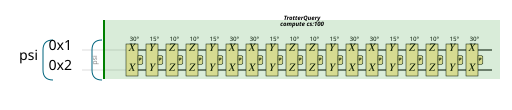

In [3]:
qpu = QPU(num_qubits=2)
psi = Qubits(2, "psi", qpu)

# Initialize and use the TrotterQuery Qubrick
trotter = TrotterQuery(hamiltonian, trotter_order)
trotter.compute(psi, trotter_steps, evolution_time)

qpu.draw(show_qubricks=True)

Note that there is some unit conversion to be handled here. In Workbench, phase angles are given in degrees by default; however, physicists typically are more comfortable working in radians. For the example above, the Hamiltonian coefficients (and therefore the rotation angles) are set to $\pi$, $\frac{\pi}{2}$ and $\frac{\pi}{3}$ for $XX$, $YY$, and $ZZ$ terms, respectively. We are using second order Trotterization, $t = 1$ and $N = 3$, so for the $XX$ term, the Pauli product rotation angle $\frac{c_jt}{2N}$ becomes $\frac{\pi \cdot 1}{2 \cdot 3} = \frac{\pi}{6} = 30^{\circ}$. Similarly, for the $YY$ and $ZZ$ terms, the rotation angles are $15^{\circ}$ and $10^{\circ}$; you can see them in the circuit diagram. 

## Using Trotterization in QPE

The result of Trotterization is a unitary operator that encodes the eigenvalues of a Hamiltonian (albeit approximately). It should therefore be of no surprise to anyone that we want to do quantum phase estimation on this operator. (If you're not familiar with this algorithm or its implementations in Workbench Algorithms, check out the [QPE tutorial](./Quantum_Phase_Estimation.ipynb).)

One of the key advantages of Qubricks-based implementations is that we can directly take the QPE Qubrick and plug Trotterization directly into it.
The following example demonstrates how to do that.

> Trotterization is often considered an "easy" subroutine compared to, say, qubitization, and thus should be learned first. However, there are many conceptual difficulties surrounding Trotterization, in large part due to the fact that the unitary encoding of the Hamiltonian is only approximate, rather than exact as with qubitization. For this reason, tests for QPE can often become muddied by unnecessary details. Rather than get into the weeds of this problem here, we instead show a very simple Hamiltonian consisting of only mutually commuting terms. The mechanics of how you would set up the problem for an actual research task are identical, but the tasks of picking an appropriate order and number of Trotter steps, handling the error analysis and preparing a valid eigenstate are left to individual research projects.

In [4]:
# Define a Hamiltonian with exactly representable phase
bits_of_precision = 3
phase = 1/2 + 1/8  # In fractions of 2pi
theta = 2 * np.pi * phase
ham = PauliSum(
    [theta, PauliMask(1, 0)],
    [theta, PauliMask(2, 0)],
    [theta, PauliMask(3, 0)],
)

# Get the eigenvalue of the Hamiltonian classically
numpy_ham = pauli_sum_to_numpy(ham)
eig_values, eig_vectors = np.linalg.eigh(numpy_ham)
print(numpy_ham.round(2))
print(f"Eigenvalue (in radians) = {eig_values[0]:.5f}")

[[0.  +0.j 3.93+0.j 3.93+0.j 3.93+0.j]
 [3.93+0.j 0.  +0.j 3.93+0.j 3.93+0.j]
 [3.93+0.j 3.93+0.j 0.  +0.j 3.93+0.j]
 [3.93+0.j 3.93+0.j 3.93+0.j 0.  +0.j]]
Eigenvalue (in radians) = -3.92699


QPE result = 0.625
Resulting eigenvalue: -3.92699, target: -3.92699


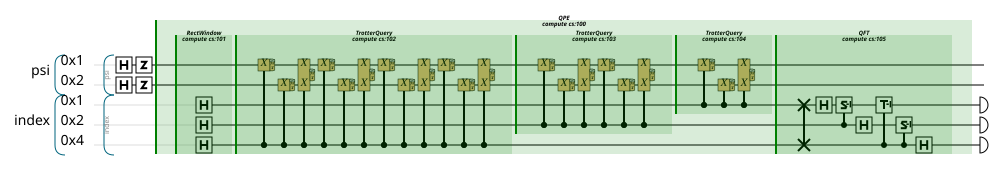

In [5]:

qpu = QPU(num_qubits=bits_of_precision + 2)
psi = Qubits(2, "psi", qpu)
index = QUFixed(bits_of_precision, bits_of_precision, "index", qpu)
# Prepare the eigenstate
psi.had()
psi.z()

evolution_time = 1
trotter_steps = 1
trotter_order = 1

trotter = TrotterQuery(hamiltonian=ham, trotter_order=trotter_order)
qpe = QPE(bits_of_precision=bits_of_precision, unitary=trotter)
qpe.compute(psi=psi, phase_reg=index, steps=trotter_steps, evo_time=evolution_time)
res_phase = index.read()
energy = - res_phase * 2 * np.pi

print(f"QPE result = {res_phase}")
print(f"Resulting eigenvalue: {energy:.5f}, target: {eig_values[0]:.5f}")
qpu.draw(show_qubricks=True)

## Implementing more sophisticated Trotter products

The construction of the product of PPRs above is a convenient way of implementing the Trotterization subroutine for general Hamiltonians, but it is not the only way. In fact, the idea of iterating over products of exponential operators is completely general, as long as you have a way of constructing the individual exponentials accurately.

If you have a more complex example problem than the simple Hamiltonian examples outlined above, you can use a more general framework for implementing operations: you can implement a [`TrotterStrategy` interface](https://construct.psiquantum.com/docs/psiqdk-algorithms/autoapi/psiqdk/algorithms/index.html#psiqdk.algorithms.TrotterStrategy).

A _strategy_ in this context refers to a software design pattern whereby one class defines an interface (which we refer to as the "strategy", as in "we'll accomplish _x_ using strategy _y_") for a particular operation, and then accepts _any_ class which implements that interface faithfully at runtime. In this case, rather than coupling the `TrotterQuery` Qubrick to the PPR implementation above, the actual Qubrick accepts a `TrotterStrategy` interface. The _only_ requirement for a class implementing a valid strategy is that it must have a method called `apply_trotter_terms` that matches the signature specified in the API above – that's it! No importing or subclassing this class, just implement and go.

> In the previous example we initialized the `TrotterQuery` Qubrick with a Hamiltonian represented as a `PauliSum`. If your use case is simple enough that everything you need can be conveniently captured by a `PauliSum`, you can do that! Under the hood, the Qubrick will apply `PauliSumTrotterStrategy` if the input is a `PauliSum`. This approach offers a balance of flexibility for advanced scenarios which need it and simplicity for the easiest cases.

### The Heisenberg Hamiltonian

One use case for this interface is to capture Hamiltonians with well-defined structures, such as spin systems. As a pedagogical example, here's an implementation of a strategy for Heisenberg model Hamiltonian:

In [6]:
from psiqdk.algorithms.utils import get_ppr_args_from_ham

class HeisenbergStrategy:
    """Implementation of a TrotterStrategy specifically tailored to Heisenberg Hamiltonians."""

    def __init__(self, lattice, J=1):
        """Initialize the strategy.

        Args:
            lattice (list): List of pairs of indices that define the lattice. In principle, would be handled robustly using
                properly defined lattices, but for the following tests we just apply some random indices.
            J (float): Coupling strength between spins in the lattice.
        """
        self.coeffs = [J]
        self.lattice = lattice

    def hamiltonian_generator(self, reverse=False):
        """Loop through edges, yield appropriate Hamiltonian terms."""
        if reverse:
            for edge in self.lattice:
                yield [self.coeffs[0], get_zz_term(edge)]
            for edge in self.lattice:
                yield [self.coeffs[0], get_yy_term(edge)]
            for edge in self.lattice:
                yield [self.coeffs[0], get_xx_term(edge)]
        else:
            for edge in self.lattice:
                yield [self.coeffs[0], get_xx_term(edge)]
            for edge in self.lattice:
                yield [self.coeffs[0], get_yy_term(edge)]
            for edge in self.lattice:
                yield [self.coeffs[0], get_zz_term(edge)]

    def apply_trotter_terms(self, factor, system, reverse=False, ctrl=0):
        """Apply the Trotterized unitary for the Hamiltonian."""
        qc = system.qpu
        if ctrl:
            anc_mask = ctrl.mask()
        for term in self.hamiltonian_generator(reverse=reverse):
            base_angle, x_mask, z_mask = get_ppr_args_from_ham(term)
            ham_x = system.mask(x_mask)
            ham_z = system.mask(z_mask)
            if ctrl:
                qc.ppr(-factor * base_angle / 2, ham_x, ham_z | anc_mask)
                qc.ppr(factor * base_angle / 2, ham_x, ham_z)
            else:
                qc.ppr(factor * base_angle, ham_x, ham_z)

# Utility functions for this Hamiltonian
def get_xx_term(pair):
    return PauliMask((1 << pair[0]) + (1 << pair[1]), 0)

def get_zz_term(pair):
    return PauliMask(0, (1 << pair[0]) + (1 << pair[1]))

def get_yy_term(pair):
    return PauliMask((1 << pair[0]) + (1 << pair[1]), (1 << pair[0]) + (1 << pair[1]))

We're not doing anything particularly exciting here, it's still effectively a `PauliSum` under the hood, but by moving to a more abstract interface, we get a few advantages:

1. We can pass around `HeisenbergStrategy` objects as a way of storing Hamiltonian instances in memory in a more intuitive way than we could using a `PauliSum`.
2. We are not storing all the terms of the Hamiltonian in memory (which in this case would be wasteful, since all the coefficients are the same and the terms have a rigid predefined structure). Instead, we're using a generator to build them on-the-fly.

To show that this works, and to demonstrate the interface, we can call `TrotterQuery` with the `HeisenbergStrategy` as the argument and see the sequence of PPRs it produces:

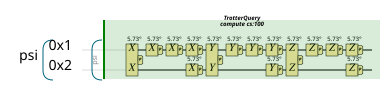

In [7]:
qpu = QPU(num_qubits=2)
psi = Qubits(2, "psi", qpu)

# Define Trotterization parameters
trotter_order = 1
trotter_steps = 1
evolution_time = 1

# Initialize the strategy
# A lattice is just a list of pairs of edges
lattice = [(0, 1), (0, 2), (0, 3), (0, 4), (1, 2)]
strategy = HeisenbergStrategy(lattice, J=0.1)

# Initialize and use the Trotter Qubrick
trotter = TrotterQuery(strategy, trotter_order)
trotter.compute(psi, trotter_steps, evolution_time)

# draw the circuit
qpu.draw(show_qubricks=True)

## Summary

In this tutorial, we went over the theory behind Trotter and Suzuki-Trotter decompositions and then learned how to represent them in Workbench Algorithms:

* `TrotterQuery` is the universal Qubrick that implements Trotter decomposition of arbitrary order for the given Hamiltonian.
* The Hamiltonian input to `TrotterQuery` can be provided as a "raw" `PauliSum` object or as a more flexible `TrotterStrategy` interface. The latter allows us to capture Hamiltonians with well-defined structures in a compact form.